In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns


### training image preprocessing

In [3]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### validation image preprocessing

In [4]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


### building model


In [25]:
from tensorflow.keras.layers import Dense,Conv2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [26]:
model=Sequential()

In [27]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [28]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [29]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [30]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [31]:
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [32]:

model.add(tf.keras.layers.Dropout(0.25))

In [33]:
model.add(Flatten())

In [34]:
model.add(Dense(units=1500,activation='relu'))

In [35]:
model.add(tf.keras.layers.Dropout(0.4))

In [36]:
## output layer
model.add(Dense(units=38,activation='softmax'))

### compile model

In [39]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_17 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_18 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_19 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

### model training

In [41]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 142s 64ms/step - loss: 1.3628 - accuracy: 0.5984 - val_loss: 0.4549 - val_accuracy: 0.8540
Epoch 2/10
2197/2197 [==============================] - 146s 66ms/step - loss: 0.4299 - accuracy: 0.8640 - val_loss: 0.3569 - val_accuracy: 0.8834
Epoch 3/10
2197/2197 [==============================] - 140s 64ms/step - loss: 0.2587 - accuracy: 0.9158 - val_loss: 0.1861 - val_accuracy: 0.9376
Epoch 4/10
2197/2197 [==============================] - 139s 63ms/step - loss: 0.1789 - accuracy: 0.9406 - val_loss: 0.2148 - val_accuracy: 0.9324
Epoch 5/10
2197/2197 [==============================] - 139s 63ms/step - loss: 0.1294 - accuracy: 0.9572 - val_loss: 0.1502 - val_accuracy: 0.9537
Epoch 6/10
2197/2197 [==============================] - 139s 63ms/step - loss: 0.1025 - accuracy: 0.9664 - val_loss: 0.1430 - val_accuracy: 0.9562
Epoch 7/10
2197/2197 [==============================] - 137s 62ms/step - loss: 0.0817 - accuracy: 0.9737 - val_loss: 0

### evaluate model

In [42]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 [==============================] - 50s 23ms/step - loss: 0.0225 - accuracy: 0.9925
Training accuracy: 0.9925314784049988


In [43]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 [==============================] - 12s 22ms/step - loss: 0.1097 - accuracy: 0.9692
Validation accuracy: 0.969155490398407


### saving model

In [45]:
model.save('trained_model.keras')


In [46]:
training_history.history

{'loss': [1.362802505493164,
  0.42987143993377686,
  0.2586587965488434,
  0.1789388805627823,
  0.129402294754982,
  0.10254105180501938,
  0.08174477517604828,
  0.06958044320344925,
  0.06155379116535187,
  0.054704535752534866],
 'accuracy': [0.5984067320823669,
  0.8640016913414001,
  0.9158119559288025,
  0.9406359195709229,
  0.9571946859359741,
  0.9663702845573425,
  0.973668098449707,
  0.9772672057151794,
  0.9804680347442627,
  0.9822177886962891],
 'val_loss': [0.45493078231811523,
  0.3569439649581909,
  0.1860821545124054,
  0.21476444602012634,
  0.1501876562833786,
  0.14302746951580048,
  0.14968788623809814,
  0.13945834338665009,
  0.1186113953590393,
  0.10970428586006165],
 'val_accuracy': [0.85402911901474,
  0.8833940625190735,
  0.9376280307769775,
  0.9324493408203125,
  0.9537332057952881,
  0.9562371969223022,
  0.952595055103302,
  0.9589118957519531,
  0.9647166132926941,
  0.969155490398407]}

In [47]:
import json
with open("training_hist.json","w")as f:
    json.dump(training_history.history,f)

### accuracy visulization

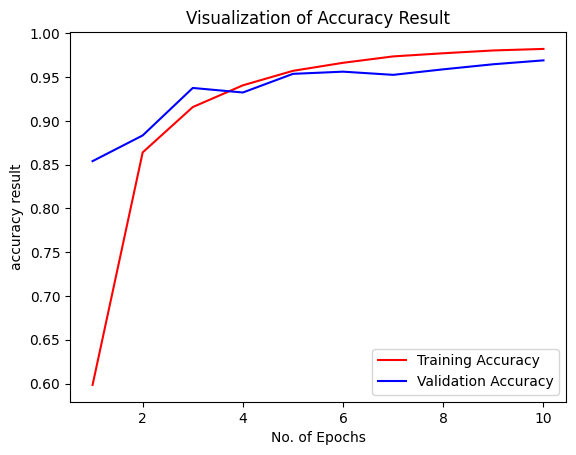

In [49]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel("accuracy result")
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

### some other metrics for model evaluation

In [50]:
class_name = validation_set.class_names

In [51]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [52]:
y_pred = model.predict(test_set)


17572/17572 [==============================] - 41s 2ms/step


In [53]:
y_pred,y_pred.shape

(array([[1.0000000e+00, 3.5799380e-10, 2.7867757e-11, ..., 1.7350435e-16,
         2.1113775e-16, 1.9940446e-14],
        [9.9999869e-01, 6.5587038e-08, 2.1773912e-09, ..., 4.0078509e-14,
         1.6796620e-13, 3.9388917e-12],
        [1.0000000e+00, 1.4095895e-10, 6.9578794e-11, ..., 2.4806088e-16,
         1.2035139e-15, 2.5890799e-13],
        ...,
        [1.7419035e-13, 9.3687976e-15, 3.8494932e-09, ..., 1.9606852e-15,
         2.0332458e-14, 1.0000000e+00],
        [7.1447123e-13, 2.6163310e-15, 1.0701694e-09, ..., 2.2835078e-14,
         5.2168519e-14, 1.0000000e+00],
        [6.3909049e-18, 5.6359077e-19, 8.4709441e-16, ..., 4.6383219e-20,
         1.2322183e-16, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [54]:
predicted_categories = tf.argmax(y_pred, axis=1)

In [55]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [56]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [57]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [58]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [59]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.95      0.97       504
                                 Apple___Black_rot       0.97      0.99      0.98       497
                          Apple___Cedar_apple_rust       0.91      0.99      0.95       440
                                   Apple___healthy       0.98      0.95      0.96       502
                               Blueberry___healthy       0.99      0.96      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.97      0.98      0.97       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.97      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.93      0.